**STEP 1: IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**STEP 2: LOAD DATASET**

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/public_transport_delays.csv')

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(2000, 24)

First 5 Rows:
  trip_id        date      time transport_type  route_id origin_station  \
0  T00000  2023-01-01  05:00:00           Tram  Route_15     Station_31   
1  T00001  2023-01-01  05:15:00          Metro  Route_12     Station_49   
2  T00002  2023-01-01  05:30:00            Bus  Route_16     Station_29   
3  T00003  2023-01-01  05:45:00           Tram  Route_19     Station_26   
4  T00004  2023-01-01  06:00:00           Tram   Route_8     Station_18   

  destination_station scheduled_departure scheduled_arrival  \
0           Station_6            05:02:00          05:55:00   
1          Station_32            05:16:00          05:55:00   
2          Station_42            05:33:00          06:17:00   
3          Station_18            05:49:00          06:08:00   
4          Station_15            06:00:00          06:35:00   

   actual_departure_delay_min  ...  wind_speed_kmh precipitation_mm  \
0                          12  ...              46        

**STEP 3: DATA CLEANING**

In [3]:
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset Shape After Cleaning:")
print(df.shape)


Missing Values:
trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

Dataset Shape After Cleaning:
(2000, 24)


**STEP 4: EXPLORATORY DATA ANALYSIS (EDA)**

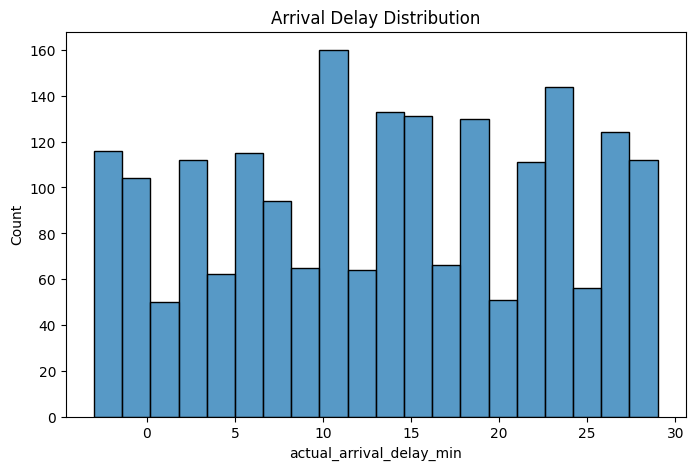

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Delay Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['actual_arrival_delay_min'], bins=20)
plt.title("Arrival Delay Distribution")
plt.show()

**Weather vs Delay**

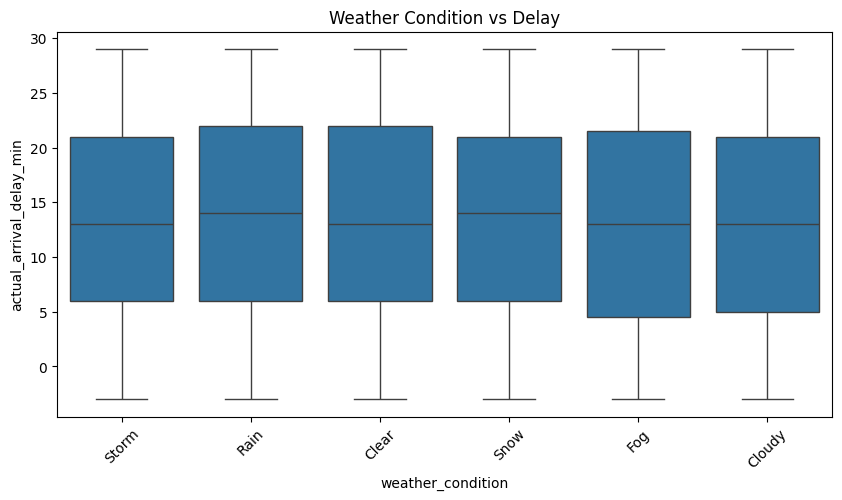

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='weather_condition',
    y='actual_arrival_delay_min',
    data=df
)
plt.xticks(rotation=45)
plt.title("Weather Condition vs Delay")
plt.show()


**Transport Type Analysis**

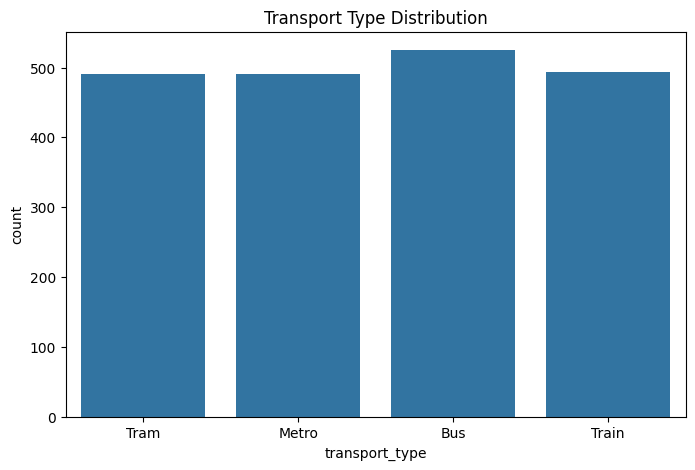

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='transport_type',
    data=df
)
plt.title("Transport Type Distribution")
plt.show()

**Traffic Congestion Analysis**

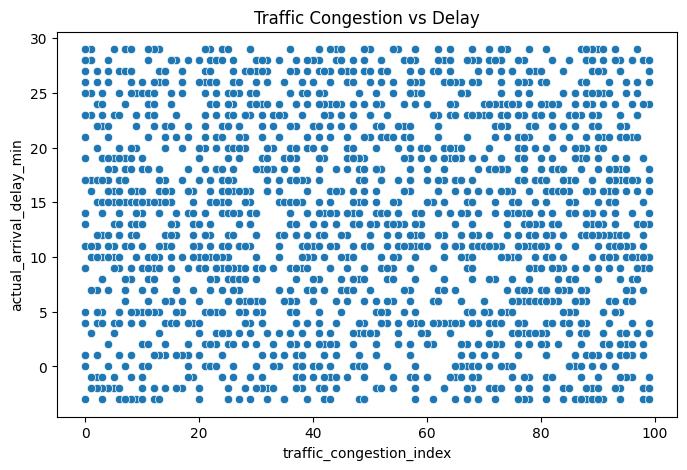

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='traffic_congestion_index',
    y='actual_arrival_delay_min',
    data=df
)
plt.title("Traffic Congestion vs Delay")
plt.show()


**Delayed vs Not Delayed**

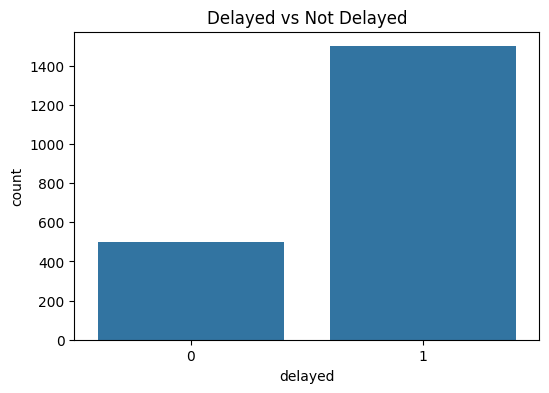

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='delayed',
    data=df
)
plt.title("Delayed vs Not Delayed")
plt.show()

**STEP 5: ENCODING CATEGORICAL COLUMNS**

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

**STEP 6: FEATURE SELECTION**

In [12]:
X = df.drop('delayed', axis=1)

y = df['delayed']

**STEP 7: TRAIN TEST SPLIT**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**STEP 8: MODEL TRAINING**

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**STEP 9: PREDICTION**

In [17]:
y_pred = model.predict(X_test)

**STEP 10: EVALUATION**

In [19]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(round(accuracy*100,2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy:
100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00       294

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



**CONFUSION MATRIX**

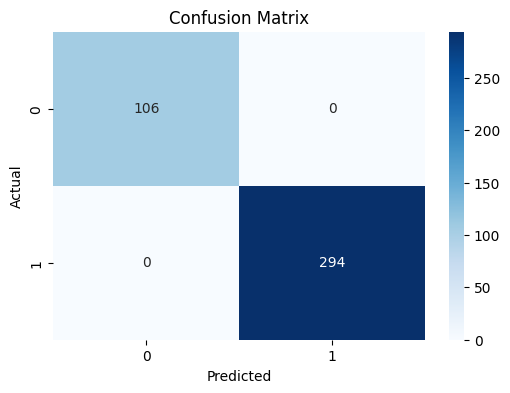

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**FEATURE IMPORTANCE**

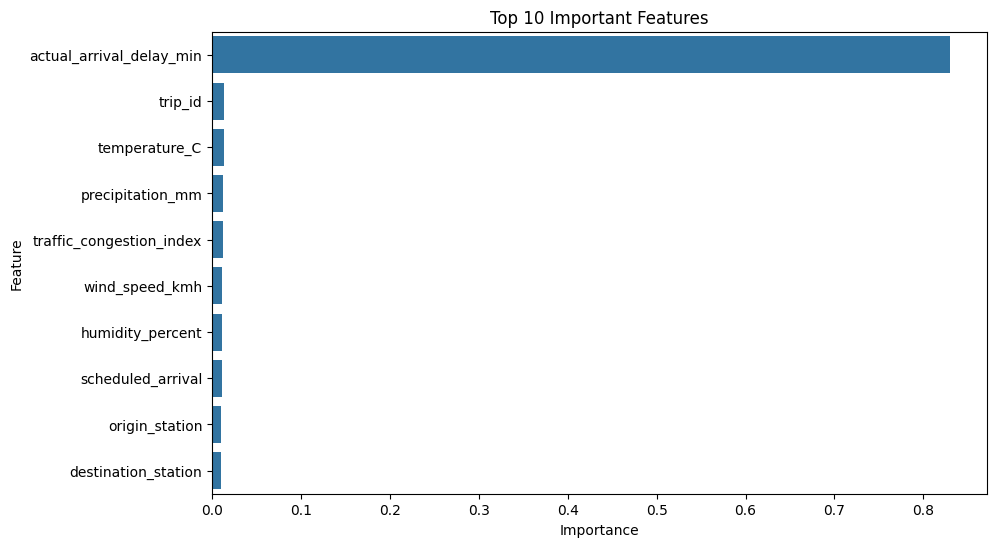


Top Important Features:
                     Feature  Importance
10  actual_arrival_delay_min    0.830117
0                    trip_id    0.013184
12             temperature_C    0.012937
15          precipitation_mm    0.012386
18  traffic_congestion_index    0.012294
14            wind_speed_kmh    0.011388
13          humidity_percent    0.010912
8          scheduled_arrival    0.010882
5             origin_station    0.009891
6        destination_station    0.009867


In [22]:
importance = model.feature_importances_

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

print("\nTop Important Features:")
print(feature_imp.head(10))